# Fraud-Detection

### Import libraries

In [1]:
# import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("libraries imported successfully")

libraries imported successfully


### LOAD DATASET + BASIC EXPLORATION

dataset loaded successfully

first 5 rows of dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10       V11       V12       V13       V14  \
0  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169   
1  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772   
2  0.247676 -1.514654  0.207643  0.624501  0.066084  0.717293 -0.165946   
3  0.377436 -1.387024 -0.054952 -0.226487  0.178228  0.507757 -0.287924   
4 -0.270533  0.817739  0.753074 -0.822843  0.538196  1.345852 -1.119670   

        

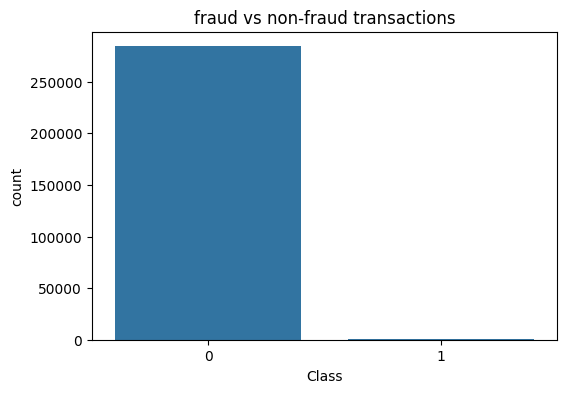


 plot saved successfully in results/plots folder


In [5]:
# load dataset

file_path = "../data/creditcard.csv"
df = pd.read_csv(file_path)

print("dataset loaded successfully\n")

# show first few rows
print("first 5 rows of dataset:")
print(df.head())

# basic info
print("\n dataset info:")
df.info()

# check shape
print("\n dataset shape:")
print(df.shape)

# check missing values
print("\n missing values:")
print(df.isnull().sum())

# class distribution
print("\n class distribution:")
print(df['Class'].value_counts())

# plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("fraud vs non-fraud transactions")

# correct save path
plt.savefig("../results/plots/class_distribution.png")

plt.show()

print("\n plot saved successfully in results/plots folder")

### DATA PREPROCESSING

In [6]:
# create a copy of dataset
df_processed = df.copy()

# scale Time and Amount
scaler = StandardScaler()
df_processed['scaled_amount'] = scaler.fit_transform(df_processed['Amount'].values.reshape(-1,1))
df_processed['scaled_time'] = scaler.fit_transform(df_processed['Time'].values.reshape(-1,1))

# drop original Time and Amount
df_processed = df_processed.drop(['Time','Amount'], axis=1)

print("data scaling completed\n")

# define features and target
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

print("features and target defined")
print("X shape:", X.shape)
print("y shape:", y.shape)

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\ntrain-test split done")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

# check class distribution after split
print("\ntrain class distribution:")
print(y_train.value_counts())

print("\ntest class distribution:")
print(y_test.value_counts())

data scaling completed

features and target defined
X shape: (284807, 30)
y shape: (284807,)

train-test split done
X_train: (227845, 30)
X_test: (56962, 30)

train class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


### EDA (EXPLORATORY DATA ANALYSIS)

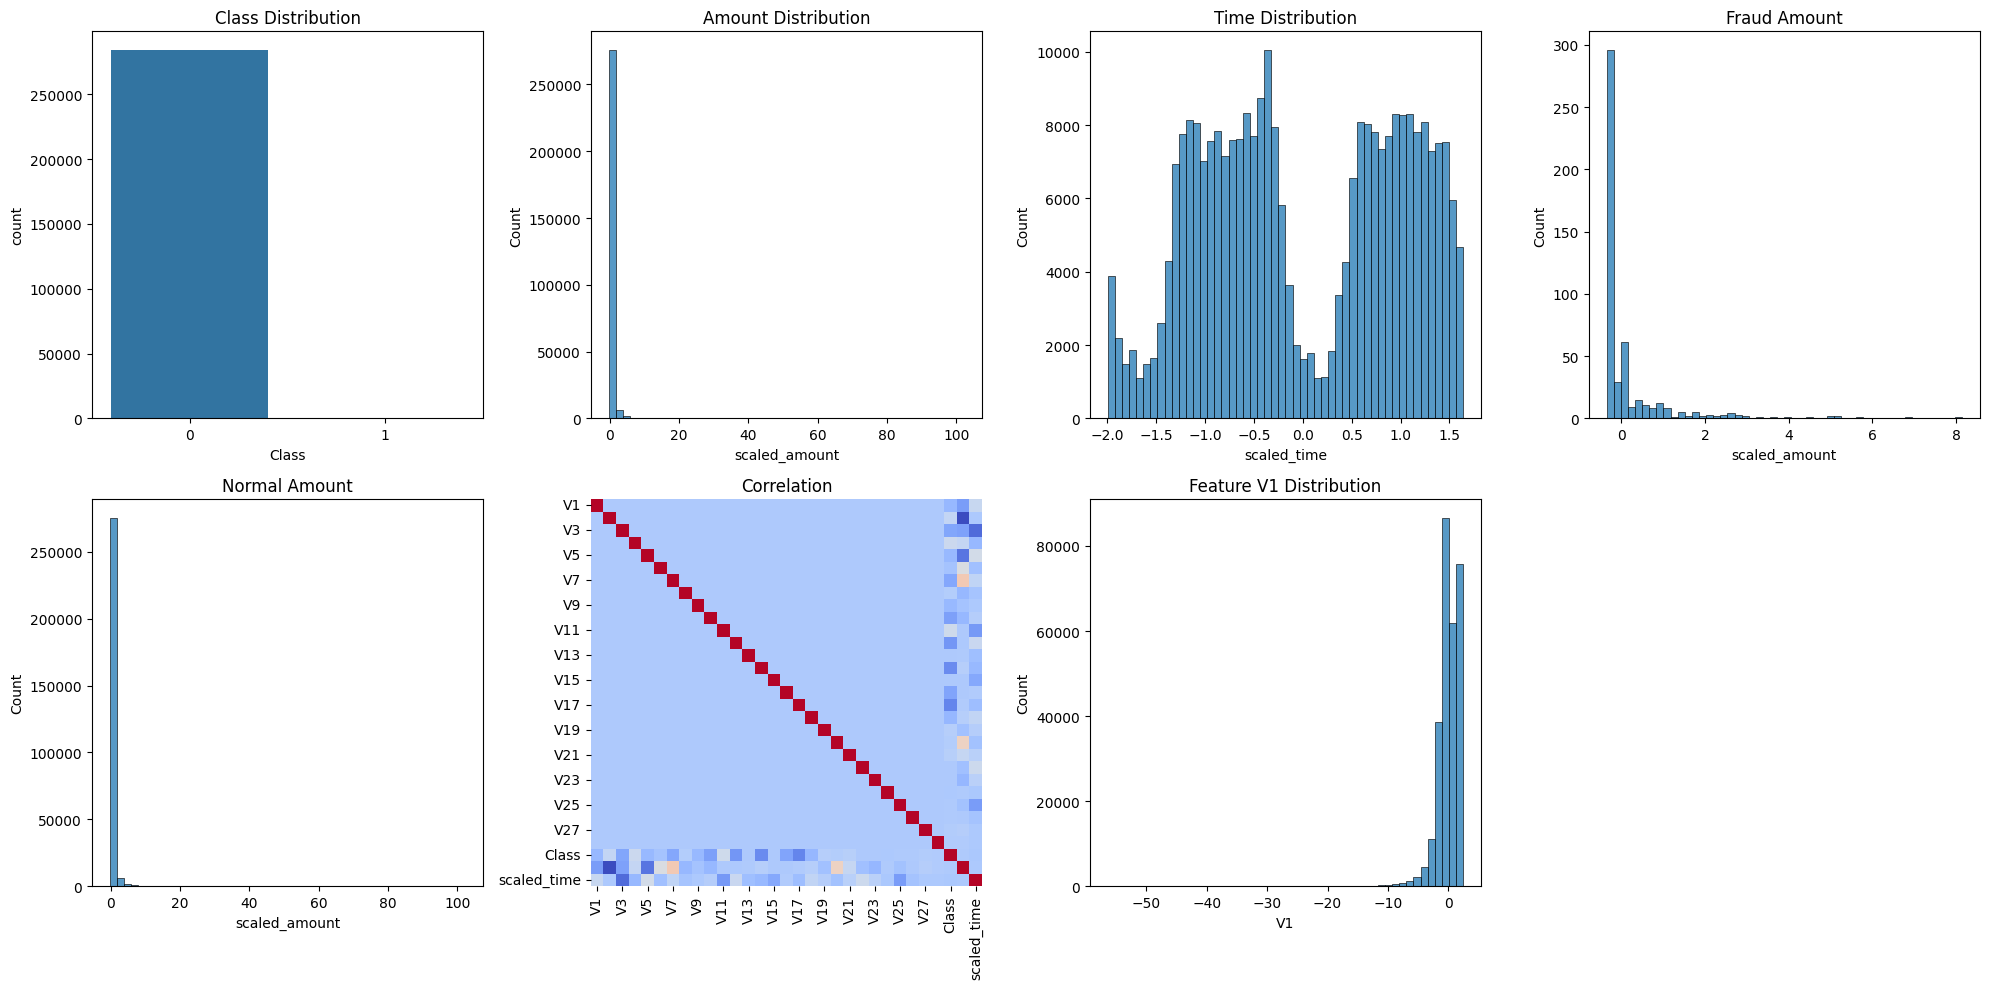

EDA plots saved successfully


In [7]:
# create multiple plots

plt.figure(figsize=(20,10))

# 1. class distribution
plt.subplot(2,4,1)
sns.countplot(x='Class', data=df_processed)
plt.title("Class Distribution")

# 2. scaled amount distribution
plt.subplot(2,4,2)
sns.histplot(df_processed['scaled_amount'], bins=50)
plt.title("Amount Distribution")

# 3. scaled time distribution
plt.subplot(2,4,3)
sns.histplot(df_processed['scaled_time'], bins=50)
plt.title("Time Distribution")

# 4. fraud amount distribution
plt.subplot(2,4,4)
sns.histplot(df_processed[df_processed['Class']==1]['scaled_amount'], bins=50)
plt.title("Fraud Amount")

# 5. normal amount distribution
plt.subplot(2,4,5)
sns.histplot(df_processed[df_processed['Class']==0]['scaled_amount'], bins=50)
plt.title("Normal Amount")

# 6. correlation heatmap (important)
plt.subplot(2,4,6)
corr = df_processed.corr()
sns.heatmap(corr, cmap='coolwarm', cbar=False)
plt.title("Correlation")

# 7. feature distribution example (V1)
plt.subplot(2,4,7)
sns.histplot(df_processed['V1'], bins=50)
plt.title("Feature V1 Distribution")

plt.tight_layout()

# save combined plot
plt.savefig("../results/plots/eda_combined.png")

plt.show()

print("EDA plots saved successfully")

### Model Development

### logistic regression model

logistic regression model trained

accuracy: 0.9991573329588147
precision: 0.8289473684210527
recall: 0.6428571428571429
f1 score: 0.7241379310344828

classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



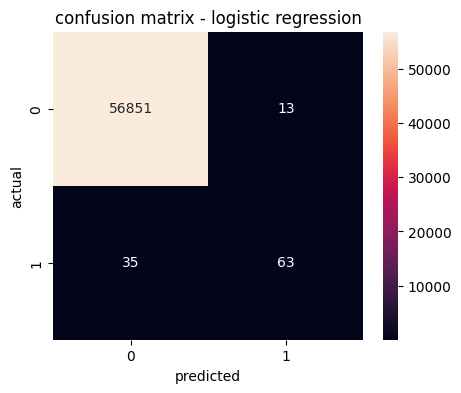

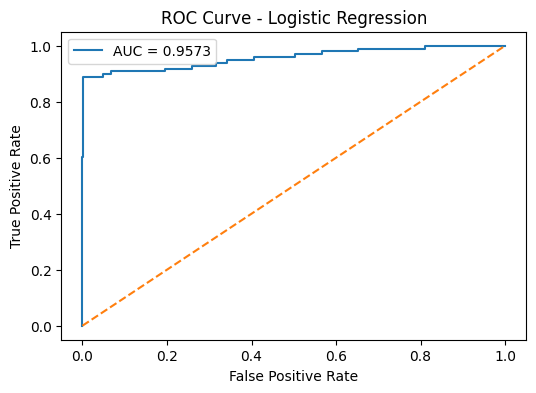

plots saved successfully


In [8]:
# logistic regression model

lr_model = LogisticRegression(max_iter=1000)

# train model
lr_model.fit(X_train, y_train)
print("logistic regression model trained\n")

# predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

# evaluation
print("accuracy:", accuracy_score(y_test, y_pred_lr))
print("precision:", precision_score(y_test, y_pred_lr))
print("recall:", recall_score(y_test, y_pred_lr))
print("f1 score:", f1_score(y_test, y_pred_lr))

print("\nclassification report:\n")
print(classification_report(y_test, y_pred_lr))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("confusion matrix - logistic regression")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.savefig("../results/plots/lr_confusion_matrix.png")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,4)))
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("../results/plots/lr_roc_curve.png")
plt.show()

print("plots saved successfully")

### Decision tree model

decision tree model trained

accuracy: 0.9994733330992591
precision: 0.9047619047619048
recall: 0.7755102040816326
f1 score: 0.8351648351648352

classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.78      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



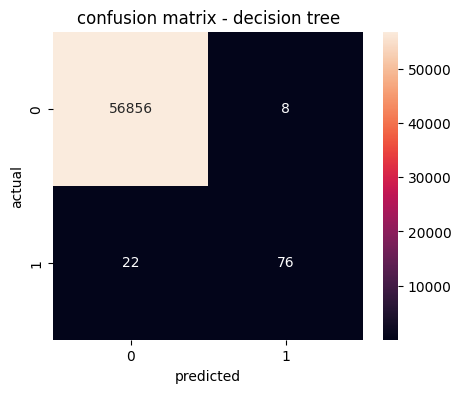

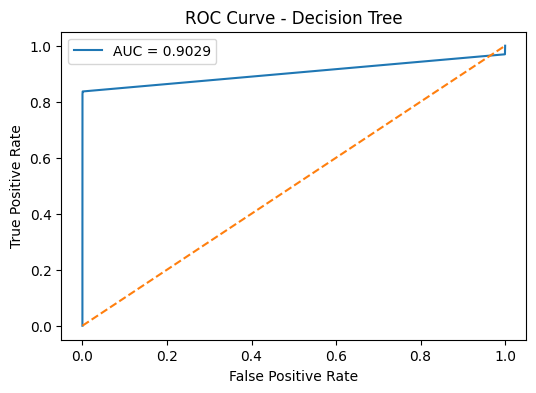

plots saved successfully


In [9]:
# decision tree model

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# train model
dt_model.fit(X_train, y_train)
print("decision tree model trained\n")

# predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

# evaluation
print("accuracy:", accuracy_score(y_test, y_pred_dt))
print("precision:", precision_score(y_test, y_pred_dt))
print("recall:", recall_score(y_test, y_pred_dt))
print("f1 score:", f1_score(y_test, y_pred_dt))

print("\nclassification report:\n")
print(classification_report(y_test, y_pred_dt))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("confusion matrix - decision tree")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.savefig("../results/plots/dt_confusion_matrix.png")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
roc_auc = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,4)))
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("../results/plots/dt_roc_curve.png")
plt.show()

print("plots saved successfully")

### Random forest model

random forest model trained

accuracy: 0.9995435553526912
precision: 0.9390243902439024
recall: 0.7857142857142857
f1 score: 0.8555555555555555

classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



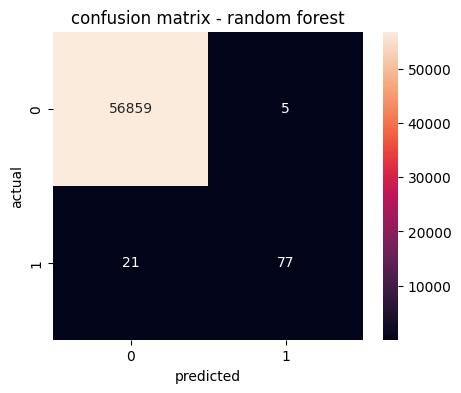

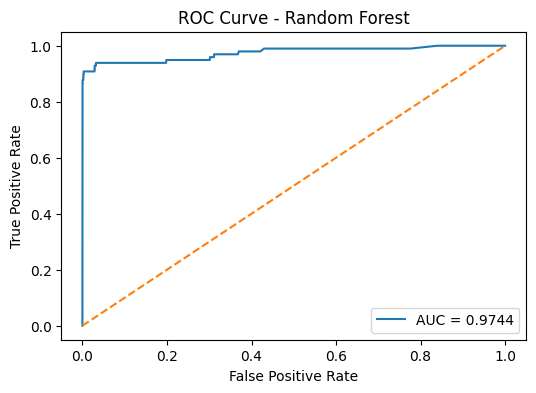

plots saved successfully


In [11]:
# faster random forest model

rf_model = RandomForestClassifier(
    n_estimators=30,        # reduced trees
    max_depth=10,           # limit depth
    n_jobs=-1,              # use all CPU cores
    random_state=42
)

# train model
rf_model.fit(X_train, y_train)
print("random forest model trained\n")

# predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# evaluation
print("accuracy:", accuracy_score(y_test, y_pred_rf))
print("precision:", precision_score(y_test, y_pred_rf))
print("recall:", recall_score(y_test, y_pred_rf))
print("f1 score:", f1_score(y_test, y_pred_rf))

print("\nclassification report:\n")
print(classification_report(y_test, y_pred_rf))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("confusion matrix - random forest")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.savefig("../results/plots/rf_confusion_matrix.png")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,4)))
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("../results/plots/rf_roc_curve.png")
plt.show()

print("plots saved successfully")

### Model comparison

In [12]:
# model comparison

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

print("\nmodel comparison:\n")
print(results)

# save results
results.to_csv("../results/metrics/model_comparison.csv", index=False)

print("\ncomparison saved successfully")


model comparison:

                 Model  Precision    Recall  F1 Score
0  Logistic Regression   0.828947  0.642857  0.724138
1        Decision Tree   0.904762  0.775510  0.835165
2        Random Forest   0.939024  0.785714  0.855556

comparison saved successfully


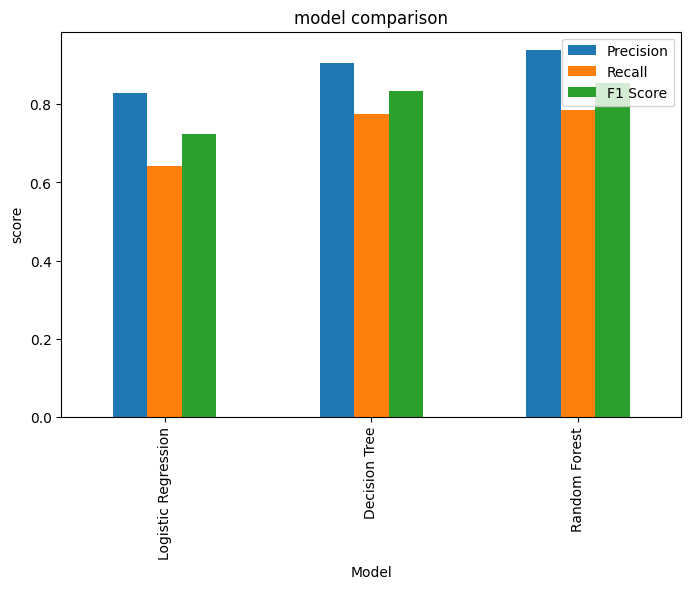

comparison plot saved


In [13]:
# plot comparison

results.set_index('Model').plot(kind='bar', figsize=(8,5))

plt.title("model comparison")
plt.ylabel("score")

plt.savefig("../results/plots/model_comparison.png")
plt.show()

print("comparison plot saved")

In [15]:
# save model and scaler properly for deployment

import joblib

# scaler you used earlier (important)
joblib.dump(scaler, "../results/models/scaler.pkl")

# save model again (just to be safe)
joblib.dump(rf_model, "../results/models/fraud_model.pkl")

print("model and scaler saved successfully")

model and scaler saved successfully


In [17]:
from sklearn.preprocessing import StandardScaler
import joblib

# create separate scalers
scaler_amount = StandardScaler()
scaler_time = StandardScaler()

# scale columns
df['scaled_amount'] = scaler_amount.fit_transform(df[['Amount']])
df['scaled_time'] = scaler_time.fit_transform(df[['Time']])

# drop original columns
df = df.drop(['Amount', 'Time'], axis=1)

# define X and y again
X = df.drop('Class', axis=1)
y = df['Class']

# split again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# train final random forest again
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=30, max_depth=10, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

# save model and scalers
joblib.dump(rf_model, "../results/models/fraud_model.pkl")
joblib.dump(scaler_amount, "../results/models/scaler_amount.pkl")
joblib.dump(scaler_time, "../results/models/scaler_time.pkl")

print("model and scalers saved successfully")

model and scalers saved successfully
